In [9]:
import numpy as np
import matplotlib.pyplot as plt
import h5py 
import sys 
import os, glob
from datetime import datetime
from zoneinfo import ZoneInfo

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(repo_root)


In [10]:
def resolve_path(path):
    if os.path.isabs(path):
        return path

    search_roots = [os.getcwd(), repo_root]
    for root in search_roots:
        candidate = os.path.abspath(os.path.join(root, path))
        if os.path.exists(candidate):
            return candidate

    return os.path.abspath(os.path.join(os.getcwd(), path))


def read_input_list(list_path):
    resolved_list_path = resolve_path(list_path)
    with open(resolved_list_path) as f_in:
        return [line.strip() for line in f_in if line.strip()]


def extract_frequency_summary(h5_path):
    with h5py.File(h5_path, "r") as h5_file:
        light_data = h5_file["light/events/data"]
        n_triggers = light_data.shape[0]
        first_event = light_data[0]
        last_event = light_data[-1]
        t_start = first_event["tai_ns"][0]
        t_end = last_event["tai_ns"][0]
        delta_t = (t_end - t_start) * 1e-9

    if delta_t <= 0:
        raise ValueError(f"Non-positive livetime found for {h5_path}")

    return {
        "file": h5_path,
        "n_triggers": n_triggers,
        "delta_t_s": delta_t,
        "trigger_frequency_hz": n_triggers / delta_t,
    }


def summarize_input_list(list_path):
    data_files = read_input_list(list_path)
    file_summaries = [extract_frequency_summary(h5_path) for h5_path in data_files]
    mean_frequency_hz = np.mean([item["trigger_frequency_hz"] for item in file_summaries])

    return {
        "label": os.path.basename(list_path).replace(".txt", ""),
        "list_path": resolve_path(list_path),
        "n_files": len(file_summaries),
        "mean_frequency_hz": mean_frequency_hz,
        "file_summaries": file_summaries,
    }


def infer_period_us(label):
    basename = os.path.basename(label)
    token = basename.split("_trigger_")[-1].split("_period")[0]
    token = token.replace("us", "")
    try:
        return float(token)
    except ValueError:
        return np.nan


In [11]:
input_lists = [
    "AmBe/AmBe_mod2_pmt_trigger_32us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_109us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_128us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_80us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_147us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_176us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_195us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_224us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_272us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_291us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_320us_period.txt",
    "AmBe/AmBe_mod2_pmt_trigger_320us_period_set_B.txt",
    
    
]

verbose = False

summaries = [summarize_input_list(list_path) for list_path in input_lists]
summaries = sorted(summaries, key=lambda item: infer_period_us(item["label"]))

for summary in summaries:
    print(
        f"{summary['label']}: {summary['n_files']} files, "
        f"mean {summary['mean_frequency_hz']:.3f} Hz"
    )

    if verbose:
        for file_summary in summary["file_summaries"]:
            print(
                f"  {os.path.basename(file_summary['file'])}: "
                f"{file_summary['trigger_frequency_hz']:.3f} Hz"
            )


AmBe_mod2_pmt_trigger_32us_period: 24 files, mean 68.549 Hz
AmBe_mod2_pmt_trigger_80us_period: 42 files, mean 79.984 Hz
AmBe_mod2_pmt_trigger_109us_period: 26 files, mean 68.782 Hz
AmBe_mod2_pmt_trigger_128us_period: 54 files, mean 71.546 Hz
AmBe_mod2_pmt_trigger_147us_period: 34 files, mean 68.752 Hz
AmBe_mod2_pmt_trigger_176us_period: 77 files, mean 63.615 Hz
AmBe_mod2_pmt_trigger_195us_period: 25 files, mean 69.155 Hz
AmBe_mod2_pmt_trigger_224us_period: 57 files, mean 70.120 Hz
AmBe_mod2_pmt_trigger_272us_period: 60 files, mean 69.665 Hz
AmBe_mod2_pmt_trigger_291us_period: 30 files, mean 68.159 Hz
AmBe_mod2_pmt_trigger_320us_period: 74 files, mean 68.500 Hz
AmBe_mod2_pmt_trigger_320us_period_set_B: 59 files, mean 66.188 Hz


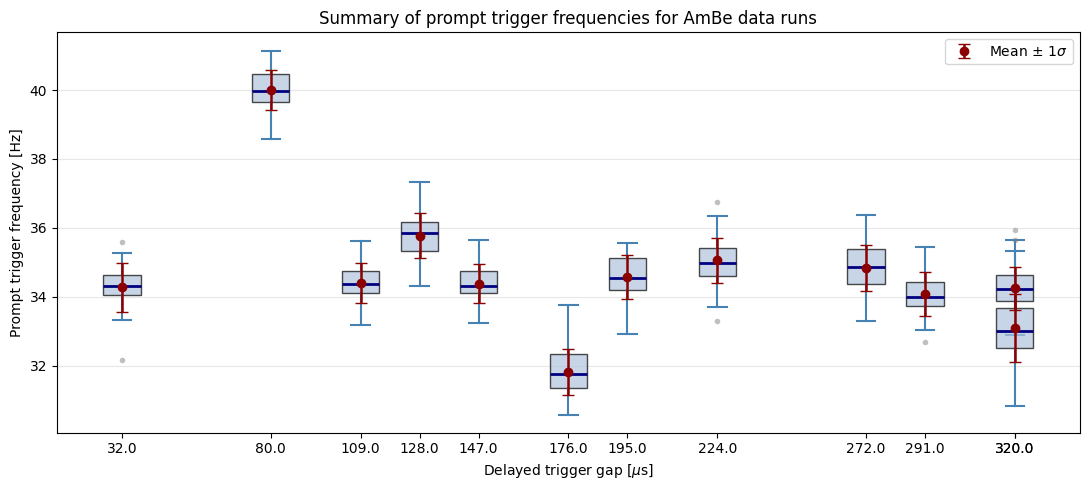

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))

boxplot_data = []
positions = []
mean_values = []
spread_values = []
sample_counts = []

for summary in summaries:
    period_us = infer_period_us(summary["label"])
    file_summaries = summary["file_summaries"]

    # Divide by two, since only half of the triggers are prompt.
    prompt_frequency_hz = np.array(
        [item["trigger_frequency_hz"] / 2.0 for item in file_summaries],
        dtype=float,
    )

    if len(prompt_frequency_hz) == 0:
        continue

    boxplot_data.append(prompt_frequency_hz)
    positions.append(period_us)
    mean_values.append(prompt_frequency_hz.mean())
    spread_values.append(prompt_frequency_hz.std(ddof=1) if len(prompt_frequency_hz) > 1 else 0.0)
    sample_counts.append(len(prompt_frequency_hz))

ax.boxplot(
    boxplot_data,
    positions=positions,
    widths=12,
    patch_artist=True,
    boxprops=dict(facecolor="lightsteelblue", alpha=0.7),
    medianprops=dict(color="navy", linewidth=2),
    whiskerprops=dict(color="steelblue", linewidth=1.5),
    capprops=dict(color="steelblue", linewidth=1.5),
    flierprops=dict(marker="o", markersize=4, markerfacecolor="gray", markeredgecolor="none", alpha=0.5),
)

ax.errorbar(
    positions,
    mean_values,
    yerr=spread_values,
    fmt="o",
    color="darkred",
    ecolor="darkred",
    elinewidth=1.8,
    capsize=4,
    label="Mean $\\pm$ 1$\\sigma$",
)


ax.set_xlabel(r"Delayed trigger gap [$\mu$s]")
ax.set_ylabel("Prompt trigger frequency [Hz]")
ax.set_title("Summary of prompt trigger frequencies for AmBe data runs")
ax.set_xticks(positions)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [13]:
# Compare raw hits with calib promp hits:
import h5flow 

mc_file = "/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_top_mod2_PROD_03-21/FLOW/2x2_QGSP_BERT_HP_AmBe_1774119367_0_TIME_MOD.FLOW.hdf5"

test_flow_entry = 0

h5_file_flow = h5flow.data.H5FlowDataManager(mc_file, 'r')

for test_flow_entry in range(100):
    raw_hits = h5_file_flow['charge/events', 'charge/raw_hits', test_flow_entry]
    calib_hits = h5_file_flow['charge/events', 'charge/calib_prompt_hits', test_flow_entry]

    len_raw = len(raw_hits.data['x_pix'][0])
    len_calib = len(calib_hits.data['x'][0])

    if(len_raw != len_calib):
        print("Number of raw hits different of calib prompt hits")

In [14]:
def get_time_stamps(h5_file,debug=True):
    t_start = h5_file['light/events/data']['utime_ms'][0][0]
    t_end = h5_file['light/events/data']['utime_ms'][-1][0]
    if(debug):
        print(f"First trigger unix time: {t_start}")
        print(f"First trigger local time: {datetime.fromtimestamp(t_start/1e3, tz=ZoneInfo('America/Chicago'))}")
        print(f"Last trigger unix time: {t_end}")
        print(f"Last trigger local time: {datetime.fromtimestamp(t_end/1e3, tz=ZoneInfo('America/Chicago'))}")
    return t_start



In [15]:
example_file = summaries[0]["file_summaries"][0]["file"]
with h5py.File(example_file, "r") as h5_file:
    get_time_stamps(h5_file)


First trigger unix time: 1762801912922
First trigger local time: 2025-11-10 13:11:52.922000-06:00
Last trigger unix time: 1762802003178
Last trigger local time: 2025-11-10 13:13:23.178000-06:00
